<img src="https://data.source.coop/taco/3dclouds/images/valencia.png" height="45">&nbsp;&nbsp;&nbsp;
<img src="https://data.source.coop/taco/3dclouds/images/oxford.png" height="45">&nbsp;&nbsp;&nbsp;
<img src="https://data.source.coop/taco/3dclouds/images/athens.png" height="45">&nbsp;&nbsp;&nbsp;
<img src="https://data.source.coop/taco/3dclouds/images/harvard.png" height="45">&nbsp;&nbsp;&nbsp;
<img src="https://data.source.coop/taco/3dclouds/images/esa.png" height="45">&nbsp;&nbsp;&nbsp;
<img src="https://data.source.coop/taco/3dclouds/images/canada.jpg" height="45">

---

# Cloud3DTACO — A Global, AI-Ready Dataset for 3D Cloud Reconstruction

*Under review*

**Cesar Aybar**¹&nbsp;&nbsp;·&nbsp;&nbsp;**Shirin Ermis**²&nbsp;&nbsp;·&nbsp;&nbsp;**Lilli Freischem**²&nbsp;&nbsp;·&nbsp;&nbsp;**Stella Girtsou**³⁴&nbsp;&nbsp;·&nbsp;&nbsp;**Kyriaki-Margarita Bintsi**⁵&nbsp;&nbsp;·&nbsp;&nbsp;**Emiliano Diaz Salas-Porras**¹&nbsp;&nbsp;·&nbsp;&nbsp;**Michael Eisinger**⁶&nbsp;&nbsp;·&nbsp;&nbsp;**William Jones**²&nbsp;&nbsp;·&nbsp;&nbsp;**Anna Jungbluth**⁶&nbsp;&nbsp;·&nbsp;&nbsp;**Benoit Tremblay**⁷

<sub>¹ Universitat de València &nbsp;|&nbsp; ² University of Oxford &nbsp;|&nbsp; ³ National Observatory of Athens &nbsp;|&nbsp; ⁴ National Technical University of Athens &nbsp;|&nbsp; ⁵ Harvard Medical School & Massachusetts General Hospital &nbsp;|&nbsp; ⁶ European Space Agency &nbsp;|&nbsp; ⁷ Environment and Climate Change Canada</sub>

---

> **Abstract.** Cloud3DTACO is an AI-ready dataset for global 3D cloud reconstruction, built on the **TACO** (Transparent Access to Cloud-Optimized datasets) specification. It pairs 2D multispectral geostationary imagery from **GOES-16**, **Himawari-8/9**, and **MSG/SEVIRI** with co-located 3D vertical cloud property profiles from **CloudSat** radar — covering the Americas, Asia-Oceania, Europe, and Africa. A dedicated benchmark subset targets **tropical cyclones** using IBTrACS storm tracks. The dataset supports self-supervised pre-training, supervised fine-tuning, and model evaluation workflows under FAIR principles.

---


## Dataset Exploration & Visualization

### Overview

This demo introduces the **TACO API** through the Cloud3DTACO pretraining split. Rather than jumping straight into model training, the goal here is to understand what the dataset contains, how it is structured, and what the imagery actually looks like.

**TACO** (Transparent Access to Cloud-Optimized datasets) is a hierarchical dataset specification for AI-ready Earth Observation data. Under the hood it stores metadata in Parquet files and imagery as Cloud-Optimized GeoTIFFs (COGs), enabling lazy queries over millions of samples without ever downloading the full dataset. The `tacoreader` library exposes this through a chainable API built on DuckDB.

By the end of this demo you will know how to:

1. **Load** a TACO dataset from source.coop with a single call
2. **Inspect** the hierarchical structure and available metadata columns
3. **Flatten** the hierarchy to get a sample-level DataFrame ready for pandas or PyTorch
4. **Filter** samples by satellite, date, and spatial bounding box
5. **Visualize** the distribution of samples across satellites and time
6. **Read and plot** individual geostationary patches band by band


### 1. Install dependencies

In [1]:
%%capture
%pip install tacoreader rasterio numpy pandas matplotlib

### 2. Load the dataset

`tacoreader.load()` is the entry point. It reads the TACO index (`COLLECTION.json` + Parquet metadata) directly from source.coop over HTTPS and registers everything into an in-memory DuckDB instance. No imagery is downloaded at this point — only the lightweight metadata tables are fetched. The call returns a `TacoDataset` object that acts as a lazy query engine.

Cloud3DTACO's pretraining split is organized into three sub-datasets, one per geostationary satellite. We load each one independently and keep them separate so we can later inspect per-satellite statistics.


In [2]:
import tacoreader

DATASET_DIR = "https://data.source.coop/taco/3dclouds/pretraining/"
SATELLITES  = ["GOES", "HIMAWARI", "MSG"]

datasets = {sat: tacoreader.load(f"{DATASET_DIR}{sat.lower()}/") for sat in SATELLITES}

for sat, ds in datasets.items():
    print(f"{sat:10s} — {ds}")

GOES       — id='cloud3d-pretraining-goes' version='0.1.0' description='GOES (Geostationary Operational Environmental Satellite) imagery subset from the Global 3D Cloud Reconstruction Dataset. Contains multispectral geostationary satellite imagery from GOES-16/ABI for 3D cloud structure reconstruction. Each sample contains 20 bands: 16 spectral channels plus satellite and solar angles. 512x512 pixel patches in Cloud-Optimized GeoTIFF format.' tasks=['regression', 'foundation-model'] extent={'spatial': [-120.93982469955046, -41.128206017560416, -1.4078382240910456, 55.50197082299586], 'temporal': ['2018-01-02T21:05:57.550000Z', '2024-12-31T23:15:06Z']} providers=[{'name': 'NOAA', 'roles': ['producer'], 'url': 'https://www.noaa.gov', 'links': None}, {'name': 'European Space Agency (ESA)', 'roles': ['licensor'], 'url': 'https://www.esa.int', 'links': None}, {'name': 'source.coop', 'roles': ['host'], 'url': 'https://source.coop', 'links': None}] licenses=['CC-BY-4.0'] title='Cloud 3D - GOE

### 3. Inspect the TACO structure

A TACO dataset is a **hierarchical tree** of metadata tables. Before flattening to a plain DataFrame, it is worth inspecting the raw structure to understand what levels exist and what columns are available at each level.

`ds.data` materializes the root-level (level-0) metadata table. For the pretraining split each root sample corresponds to a single scene acquisition. The columns prefixed with `l0:` are TACO-standard fields; columns prefixed with `l0:stac:` follow the STAC metadata convention.

In [3]:
ds = datasets["GOES"]

# Root-level metadata (level 0)
level0 = ds.data
print("Level-0 shape :", level0.shape)
print("Columns       :", level0.columns)
level0.head(3)

Level-0 shape : (91423, 19)
Columns       : ['id', 'type', 'cloud3d:cyclone', 'cloud3d:satellite', 'geoenrich:admin_countries', 'geoenrich:elevation', 'geoenrich:precipitation', 'geoenrich:temperature', 'geotiff:stats', 'majortom:code', 'stac:centroid', 'stac:crs', 'stac:geotransform', 'stac:tensor_shape', 'stac:time_end', 'stac:time_middle', 'stac:time_start', 'taco:header', 'internal:gdal_vsi']


pyarrow.Table
id: string
type: string
cloud3d:cyclone: bool
cloud3d:satellite: string
geoenrich:admin_countries: string
geoenrich:elevation: float
geoenrich:precipitation: float
geoenrich:temperature: float
geotiff:stats: list<l: list<l: float>>
  child 0, l: list<l: float>
      child 0, l: float
majortom:code: string
stac:centroid: binary
stac:crs: string
stac:geotransform: list<l: double>
  child 0, l: double
stac:tensor_shape: list<l: int64>
  child 0, l: int64
stac:time_end: timestamp[us]
stac:time_middle: timestamp[us]
stac:time_start: timestamp[us]
taco:header: binary
internal:gdal_vsi: string
----
id: [["20180606000050_2018157N14255","20180606001550_2018157N14255","20180606003050_2018157N14255"]]
type: [["FILE","FILE","FILE"]]
cloud3d:cyclone: [[true,true,true]]
cloud3d:satellite: [["GOES","GOES","GOES"]]
geoenrich:admin_countries: [["Ocean/Sea/Lakes","Ocean/Sea/Lakes","Ocean/Sea/Lakes"]]
geoenrich:elevation: [[0,0,0]]
geoenrich:precipitation: [[1.3825237,1.3825237,1.3825237]]


### 4. Flatten to a sample-level DataFrame

The `.flatten()` method expands the full TACO hierarchy into a single flat DataFrame where each row is a leaf-level sample — in this case, an individual 512×512 scene patch. The key column it exposes is `gdal_vsi`: a GDAL-compatible virtual filesystem path that `rasterio` can use to stream the COG directly from source.coop without downloading it.

We flatten all three satellites and concatenate them into a single DataFrame for joint analysis.


In [4]:
import pandas as pd

dfs = []
for sat, ds in datasets.items():
    f = ds.flatten()
    dfs.append(pd.DataFrame({
        "satellite": sat,                                   # use loop variable — always safe
        "date":      pd.to_datetime(f["l0:stac:time_start"]),
        "gdal_vsi":  f["gdal_vsi"],
    }))

df = pd.concat(dfs, ignore_index=True)
df["month"] = df["date"].dt.to_period("M")

print(f"Total samples : {len(df):,}")
print(f"Date range    : {df['date'].min().date()} → {df['date'].max().date()}")
print(df.groupby("satellite").size().rename("n_samples"))

Total samples : 230,134
Date range    : 2004-01-19 → 2025-02-28
satellite
GOES        91423
HIMAWARI    88711
MSG         50000
Name: n_samples, dtype: int64


## 5. Filter samples

One of the main features of the TACO API is its ability to filter lazily — queries run in DuckDB against the Parquet metadata before any imagery is touched. Filters can be chained and combined freely.

**Filter by date** using an ISO 8601 interval string:

In [5]:
# All GOES scenes acquired in July 2020
goes_july = datasets["GOES"].filter_datetime("2020-07-01/2020-07-01")
print(f"GOES scenes in July 2020: {len(goes_july.flatten())}")

GOES scenes in July 2020: 26


**Filter by bounding box** — the `level` parameter controls which tree level the spatial filter applies to:


In [6]:
# HIMAWARI scenes over Japan (level-0 = scene centroid must intersect bbox)
japan_bbox = datasets["HIMAWARI"].filter_bbox(129, 30, 146, 46, level=0)
print(f"Himawari scenes over Japan: {len(japan_bbox.flatten())}")

Himawari scenes over Japan: 4099


**Chain multiple filters** and run a custom SQL query on top:

In [7]:
# GOES scenes from 2021, northern hemisphere only, ordered by date
result = (
    datasets["GOES"]
    .filter_datetime("2021-01-01/2021-12-31")
    .filter_bbox(-180, 0, 180, 90, level=0)
    .sort("l0:stac:time_start", descending=False)
    .limit(500)
)
filtered_df = pd.DataFrame({
    "id":   result.flatten()["l0:id"],
    "date": pd.to_datetime(result.flatten()["l0:stac:time_start"]),
})
print(f"Filtered samples: {len(filtered_df)}")
filtered_df.head()

Filtered samples: 500


,id,date
0,20210101014020_3435_1821,2021-01-01 01:40:20.900
1,20210101040020_2551_1862,2021-01-01 04:00:20.900
2,20210101051021_2523_1918,2021-01-01 05:10:21.100
3,20210101054021_489_1245,2021-01-01 05:40:21.100
4,20210101060021_2902_1277,2021-01-01 06:00:21.100


## 6. Temporal & spatial distribution

Now that we have the full flattened DataFrame, let's plot where and when the samples were collected. This gives a quick sanity check that global coverage is reasonable and that the three satellites complement each other geographically.


/tmp/ipykernel_239/3101342944.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


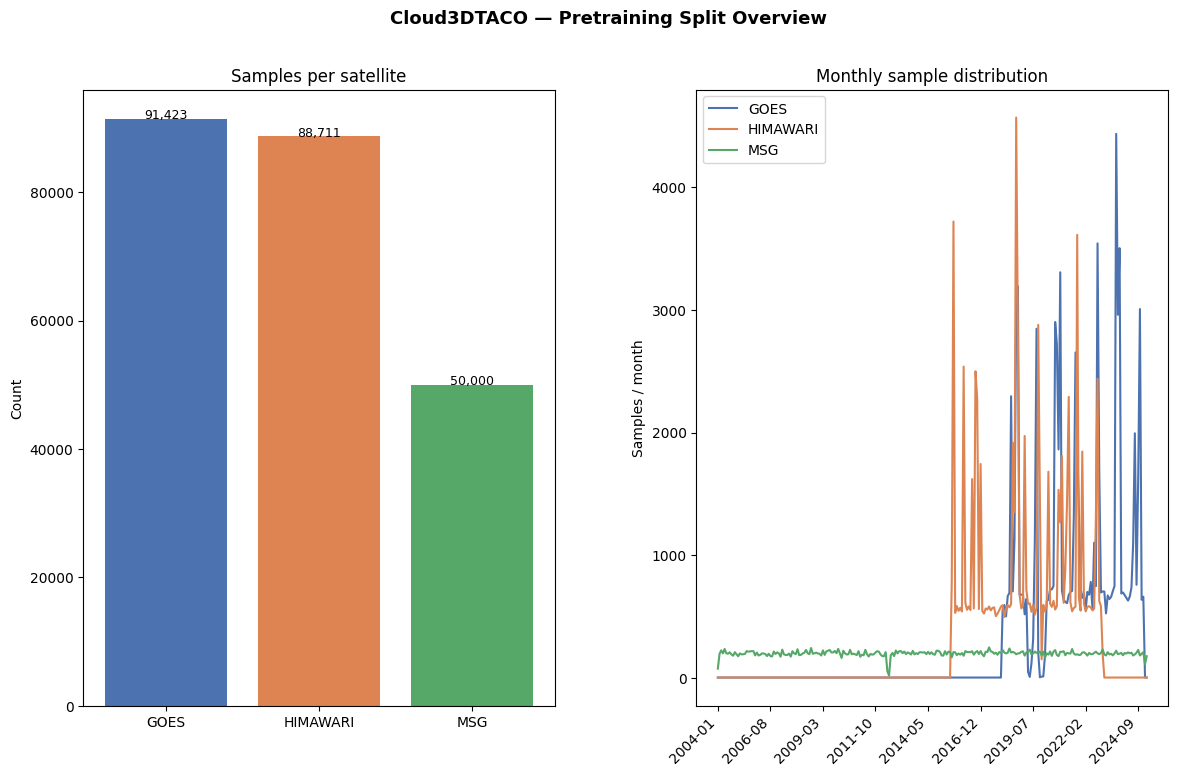

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SAT_COLORS = {"GOES": "#4C72B0", "HIMAWARI": "#DD8452", "MSG": "#55A868"}

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)

# --- Samples per satellite ---
ax0 = fig.add_subplot(gs[0, 0])
counts = df.groupby("satellite").size()
ax0.bar(counts.index, counts.values, color=[SAT_COLORS[s] for s in counts.index])
ax0.set_title("Samples per satellite")
ax0.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax0.text(i, v + 10, f"{v:,}", ha="center", fontsize=9)

# --- Monthly distribution ---
ax1 = fig.add_subplot(gs[0, 1])
all_months = sorted(df["month"].unique())
month_strs = [str(m) for m in all_months]

for sat in SATELLITES:
    sub     = df[df["satellite"] == sat]
    monthly = sub.groupby("month").size().reindex(all_months, fill_value=0)
    ax1.plot(month_strs, monthly.values, label=sat, color=SAT_COLORS[sat], linewidth=1.5)

tick_step = max(1, len(month_strs) // 8)
ax1.set_xticks(range(0, len(month_strs), tick_step))
ax1.set_xticklabels(month_strs[::tick_step], rotation=45, ha="right")
ax1.set_title("Monthly sample distribution")
ax1.set_ylabel("Samples / month")
ax1.legend()

plt.suptitle("Cloud3DTACO — Pretraining Split Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("cloud3d_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Read and visualize individual patches

Finally, let's stream an actual patch for each satellite and visualize several band combinations. The `gdal_vsi` column contains the path that `rasterio` needs — it resolves directly to the COG on source.coop via a GDAL virtual filesystem URI. Only the requested bands are transferred over the network.

We visualize three complementary views for each scene: a **true-colour RGB** (red + NIR as green proxy + NIR), a **thermal IR** brightness temperature, and a **water vapour** channel that highlights mid-tropospheric moisture structures.


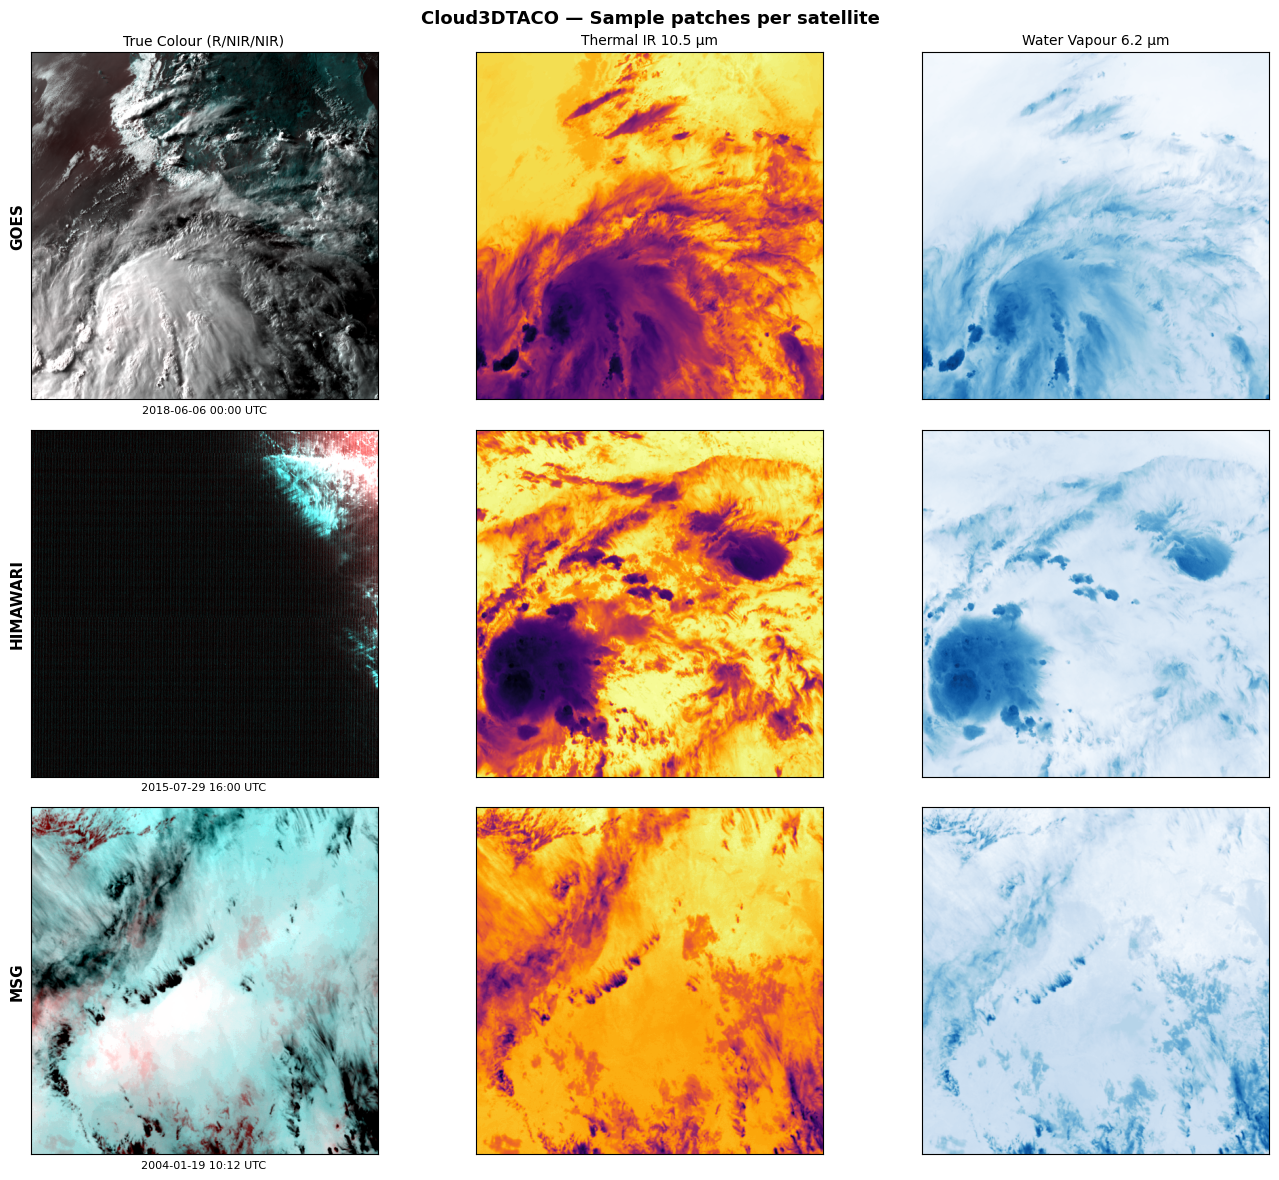

In [9]:

import rasterio
import numpy as np
import matplotlib.pyplot as plt

BAND_MAPPING = {
    "GOES":     [1, 2, 4, 6, 7, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19],
    "HIMAWARI": [2, 3, 4, 6, 7, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19],
    "MSG":      [9, 10, 0, 1, 2, 3,  4,  5,  6,  7,  8, 11, 12, 13, 14],
}
IDX = {"red": 0, "nir": 1, "wv_6.2": 4, "ir_10.5": 8}


def pstretch(band, plow=2, phigh=98):
    lo, hi = np.percentile(band[np.isfinite(band)], [plow, phigh])
    return np.clip((band - lo) / (hi - lo + 1e-10), 0, 1)


def read_patch(vsi, sat):
    bands_1idx = [b + 1 for b in BAND_MAPPING[sat]]
    with rasterio.open(vsi) as src:
        return src.read(bands_1idx).astype(np.float32)


fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle("Cloud3DTACO — Sample patches per satellite", fontsize=13, fontweight="bold")

for ax, t in zip(axes[0], ["True Colour (R/NIR/NIR)", "Thermal IR 10.5 µm", "Water Vapour 6.2 µm"]):
    ax.set_title(t, fontsize=10)

for row, sat in enumerate(SATELLITES):
    sample = df[df["satellite"] == sat].iloc[0]
    img    = read_patch(sample["gdal_vsi"], sat)

    r   = pstretch(img[IDX["red"]])
    nir = pstretch(img[IDX["nir"]])
    rgb = np.stack([r, nir, nir], axis=-1)

    axes[row, 0].imshow(rgb)
    axes[row, 1].imshow(img[IDX["ir_10.5"]], cmap="inferno")
    axes[row, 2].imshow(img[IDX["wv_6.2"]],  cmap="Blues_r")
    axes[row, 0].set_ylabel(sat, fontsize=11, fontweight="bold")
    axes[row, 0].set_xlabel(sample["date"].strftime("%Y-%m-%d %H:%M UTC"), fontsize=8)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig("cloud3d_patches.png", dpi=150, bbox_inches="tight")
plt.show()